In [197]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [198]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [199]:

# Cargar el dataset principal de solicitudes de adelanto en efectivo
cash_request = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/extract - cash request - data analyst.csv')


In [200]:
cr = cash_request.copy()


In [201]:
# Filtrar columnas relevantes para el análisis
cr = cr[["amount", "created_at", "user_id", "deleted_account_id", "transfer_type"]]
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amount              23970 non-null  float64
 1   created_at          23970 non-null  object 
 2   user_id             21867 non-null  float64
 3   deleted_account_id  2104 non-null   float64
 4   transfer_type       23970 non-null  object 
dtypes: float64(3), object(2)
memory usage: 936.5+ KB


In [202]:
# Rellenar valores nulos en 'user_id' usando 'deleted_account_id'
# (clientes transferidos de cuentas eliminadas)
cr.fillna({"user_id": cr["deleted_account_id"]}, inplace=True)


In [203]:
# Eliminar la columna 'deleted_account_id' ya que no es necesaria después de la imputación
cr.drop(columns=["deleted_account_id"], inplace=True)
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   amount         23970 non-null  float64
 1   created_at     23970 non-null  object 
 2   user_id        23970 non-null  float64
 3   transfer_type  23970 non-null  object 
dtypes: float64(2), object(2)
memory usage: 749.2+ KB


In [204]:
# Convertir 'created_at' a tipo datetime para manipulación de fechas
cr['created_at'] = pd.to_datetime(cr['created_at'])
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873+00:00,804.0,regular
1,100.0,2019-12-10 19:50:12.347780+00:00,231.0,regular
2,100.0,2019-12-10 19:13:35.825460+00:00,191.0,regular
3,99.0,2019-12-10 19:16:10.880172+00:00,761.0,regular
4,100.0,2020-05-06 09:59:38.877376+00:00,7686.0,regular


In [205]:
# Convertir la columna 'created_at' a una fecha sin zona horaria
cr['created_at'] = cr['created_at'].dt.tz_localize(None)
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873,804.0,regular
1,100.0,2019-12-10 19:50:12.347780,231.0,regular
2,100.0,2019-12-10 19:13:35.825460,191.0,regular
3,99.0,2019-12-10 19:16:10.880172,761.0,regular
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular


In [206]:
# Crear columna 'Mes' indicando el mes de cada solicitud
cr['Semana'] = cr['created_at'].dt.to_period('W')
cr.head()


,amount,created_at,user_id,transfer_type,Semana
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10


In [207]:
# Crear columna 'Cohorte' que indica el mes de la primera solicitud de cada cliente
cr['Cohorte'] = cr.groupby('user_id')['created_at'].transform('min').dt.to_period('W')
cr.head(10)


,amount,created_at,user_id,transfer_type,Semana,Cohorte
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10,2020-05-04/2020-05-10
5,100.0,2020-05-23 20:58:55.129432,9489.0,regular,2020-05-18/2020-05-24,2020-05-18/2020-05-24
6,100.0,2020-06-16 17:07:38.452652,14631.0,regular,2020-06-15/2020-06-21,2020-06-15/2020-06-21
7,100.0,2020-02-10 01:11:53.808270,309.0,regular,2020-02-10/2020-02-16,2020-01-27/2020-02-02
8,100.0,2020-06-28 12:06:33.712840,2499.0,regular,2020-06-22/2020-06-28,2020-06-22/2020-06-28
9,90.0,2019-12-10 19:51:23.911206,897.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15


In [208]:
# Agregar columnas de temporalidad

# Semana y mes de la solicitud
cr['Semana_Mes'] = cr['created_at'].dt.strftime('%U_%B') + '_' + cr['Semana'].dt.strftime('%Y')

# Día y semana de la solicitud
cr['Dia_Semana'] = cr['created_at'].dt.strftime('%A') + '_' + cr['Semana_Mes']

# Hora y día de la solicitud
cr['Hora_Dia'] = cr['created_at'].dt.hour.astype(str) + '_' + cr['Dia_Semana']

cr.head()


,amount,created_at,user_id,transfer_type,Semana,Cohorte,Semana_Mes,Dia_Semana,Hora_Dia
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12-09/2019-12-15,2019-12-09/2019-12-15,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05-04/2020-05-10,2020-05-04/2020-05-10,18_May_2020,Wednesday_18_May_2020,9_Wednesday_18_May_2020


In [209]:
# Calcular la cantidad de adelanto de efectivo por cohorte y mes
cohort_revenue = cr.groupby(['Cohorte', 'Semana'])['amount'].sum().reset_index()

# Crear tabla pivote con Cohorte como índice y Mes como columnas
cohort_revenue = cohort_revenue.pivot(index='Cohorte', columns='Semana', values='amount')

cohort_revenue


Semana,2019-11-18/2019-11-24,2019-12-09/2019-12-15,2019-12-16/2019-12-22,2019-12-23/2019-12-29,2019-12-30/2020-01-05,2020-01-06/2020-01-12,2020-01-13/2020-01-19,2020-01-20/2020-01-26,2020-01-27/2020-02-02,2020-02-03/2020-02-09,...,2020-08-24/2020-08-30,2020-08-31/2020-09-06,2020-09-07/2020-09-13,2020-09-14/2020-09-20,2020-09-21/2020-09-27,2020-09-28/2020-10-04,2020-10-05/2020-10-11,2020-10-12/2020-10-18,2020-10-19/2020-10-25,2020-10-26/2020-11-01
Cohorte,,,,,,,,,,,,,,,,,,,,,
2019-11-18/2019-11-24,1.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,1.0
2019-12-09/2019-12-15,NaN,10026.0,770.0,810.0,1050.0,1320.0,1515.0,460.0,870.0,650.0,...,150.0,650.0,1000.0,450.0,400.0,100.0,450.0,1130.0,300.0,350.0
2019-12-16/2019-12-22,NaN,NaN,10321.0,550.0,1190.0,1250.0,700.0,860.0,448.0,801.0,...,300.0,600.0,900.0,210.0,NaN,200.0,950.0,650.0,275.0,550.0
2019-12-23/2019-12-29,NaN,NaN,NaN,3180.0,100.0,200.0,300.0,200.0,300.0,400.0,...,NaN,350.0,NaN,300.0,50.0,100.0,500.0,650.0,150.0,150.0
2019-12-30/2020-01-05,NaN,NaN,NaN,NaN,1300.0,200.0,NaN,100.0,100.0,200.0,...,NaN,100.0,300.0,50.0,NaN,100.0,250.0,NaN,NaN,NaN
2020-01-06/2020-01-12,NaN,NaN,NaN,NaN,NaN,2900.0,100.0,200.0,498.0,300.0,...,200.0,NaN,200.0,100.0,NaN,NaN,100.0,100.0,100.0,250.0
2020-01-13/2020-01-19,NaN,NaN,NaN,NaN,NaN,NaN,1050.0,NaN,80.0,180.0,...,100.0,50.0,NaN,NaN,100.0,NaN,100.0,100.0,NaN,200.0
2020-01-20/2020-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1200.0,300.0,200.0,...,NaN,260.0,60.0,NaN,50.0,100.0,NaN,150.0,NaN,100.0
2020-01-27/2020-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5406.0,600.0,...,NaN,400.0,200.0,300.0,350.0,100.0,200.0,450.0,200.0,200.0


In [ ]:

cohort_revenue = cohort_revenue.drop(columns=cohort_revenue.columns[:3])
cohort_revenue

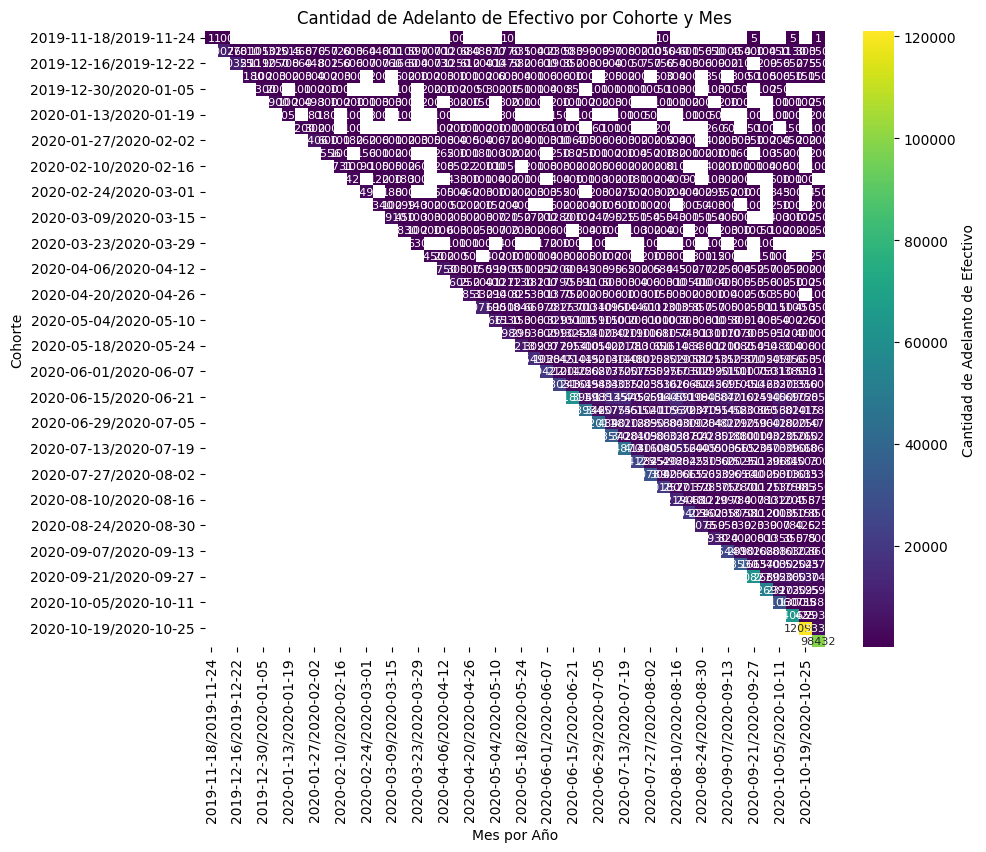

In [211]:
# Graficar la cantidad de adelanto de efectivo por cohorte y mes
plt.figure(figsize=(10, 8))
plt.title('Cantidad de Adelanto de Efectivo por Cohorte y Mes')

sns.heatmap(
    data=cohort_revenue,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Cantidad de Adelanto de Efectivo'}
)

plt.xlabel('Mes por Año')
plt.ylabel('Cohorte')
plt.show()



📊 Evaluación del Modelo:
RMSE Interpolación: 1362.782, RMSE Extrapolación: 404.276
R² Interpolación: -10.672, R² Extrapolación: -11.329

🔍 Valores negativos en extrapolación:
[]


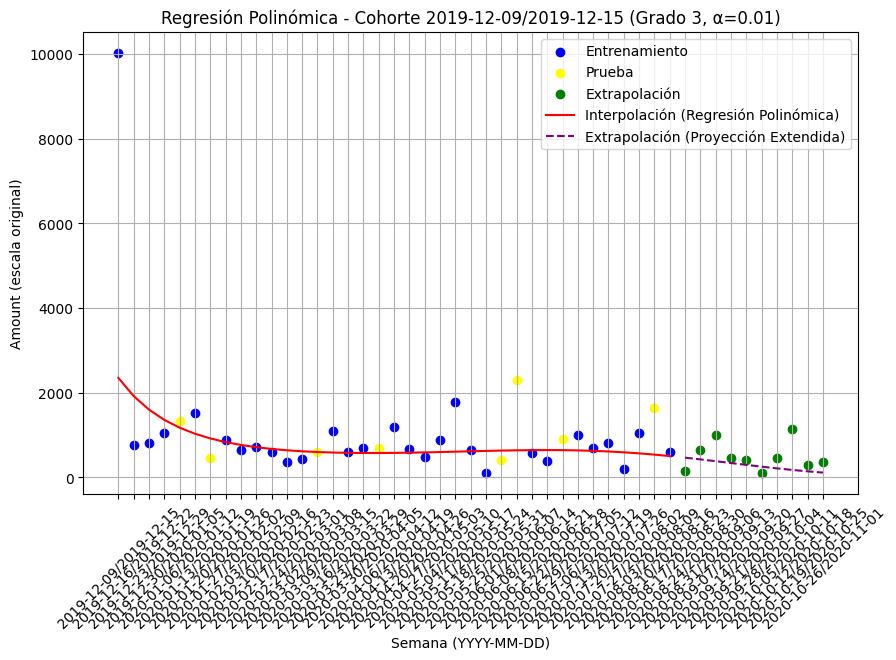

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Aplicar regresión polinómica con Ridge
degree = 3  # Ajustar grado si es necesario
alpha = 0.01  # Regularización

poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 🔹 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)
y_extrap_pred = model.predict(X_extrap_poly)

# 🔹 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 9️⃣ Evaluación del modelo
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

print(f"\n📊 Evaluación del Modelo:")
print(f"RMSE Interpolación: {rmse_interp:.3f}, RMSE Extrapolación: {rmse_extrap:.3f}")
print(f"R² Interpolación: {r2_interp:.3f}, R² Extrapolación: {r2_extrap:.3f}")

# 🔍 Verificar valores negativos en extrapolación
print("\n🔍 Valores negativos en extrapolación:")
print(y_extrap_pred[y_extrap_pred < 0])

# 🔹 🔄 Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección Extendida)')

# Configuración de la gráfica
plt.xticks(X.flatten(), cohort_2019_12_09.index, rotation=45)
plt.xlabel("Semana (YYYY-MM-DD)")
plt.ylabel("Amount (escala original)")
plt.title(f"Regresión Polinómica - Cohorte {semana_objetivo} (Grado {degree}, α={alpha})")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


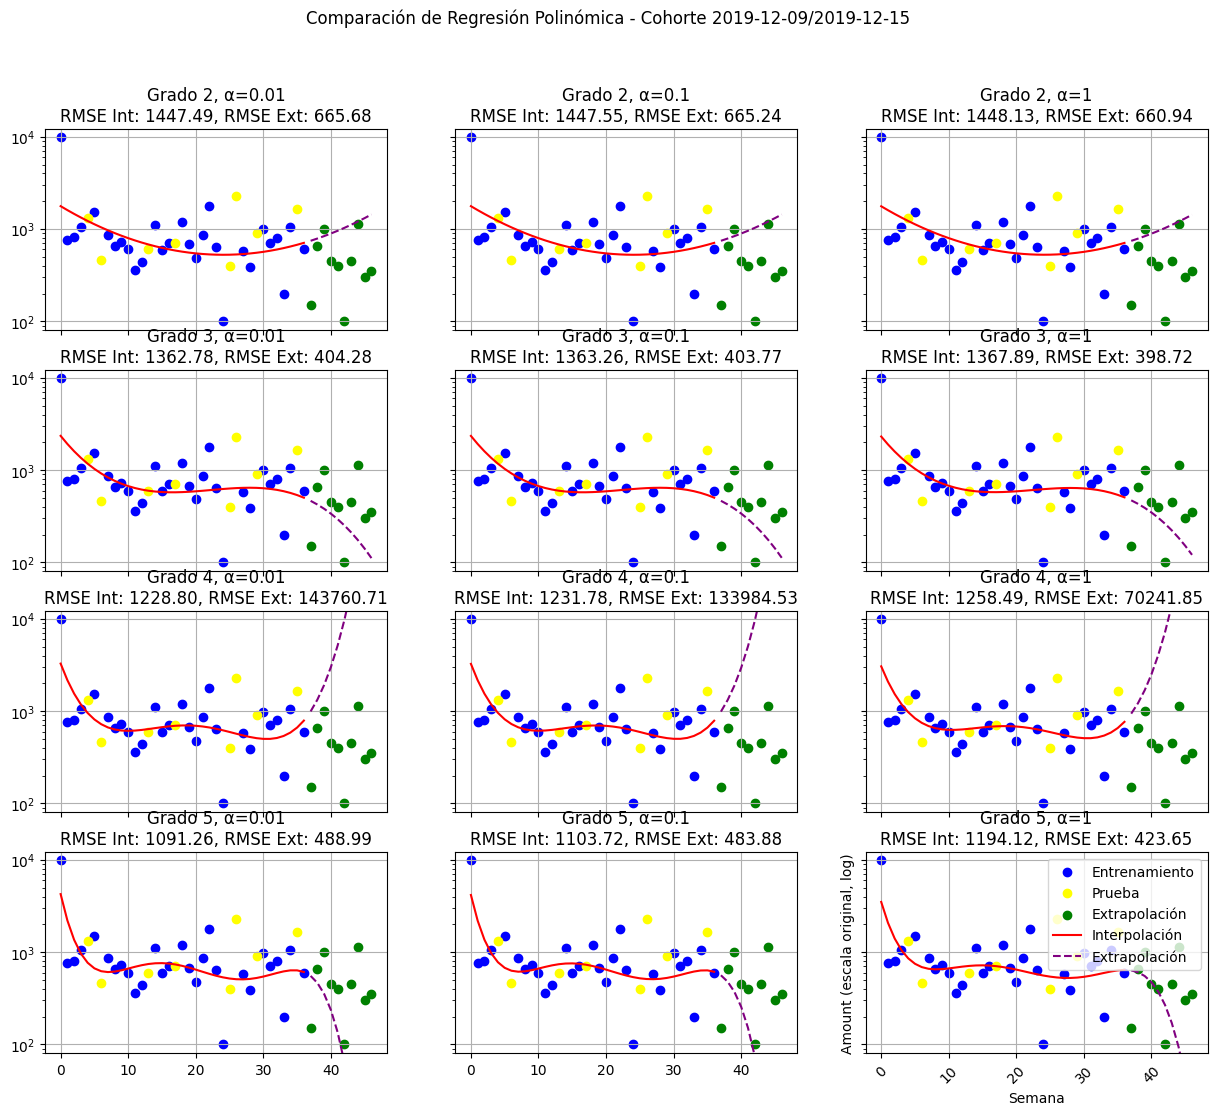

In [213]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Probar múltiples valores de `degree` y `alpha`
degrees = [2, 3, 4, 5]
alphas = [0.01, 0.1, 1]

fig, axes = plt.subplots(len(degrees), len(alphas), figsize=(15, 12), sharex=True, sharey=True)

# Determinar los límites del eje Y
y_min, y_max = np.expm1(y).min(), np.expm1(y).max()

for i, degree in enumerate(degrees):
    for j, alpha in enumerate(alphas):
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        X_interp_poly = poly.transform(X_interp)
        X_extrap_poly = poly.transform(X_extrap)

        model = Ridge(alpha=alpha)
        model.fit(X_train_poly, y_train)

        # Predicciones
        y_interp_pred = model.predict(X_interp_poly)
        y_extrap_pred = model.predict(X_extrap_poly)

        # Volver a la escala original
        y_interp_pred = np.expm1(y_interp_pred)
        y_extrap_pred = np.expm1(y_extrap_pred)
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_extrap_orig = np.expm1(y_extrap)

        # Evaluación del modelo
        rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
        rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
        r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
        r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

        # Graficar resultados
        ax = axes[i, j]
        ax.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
        ax.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
        ax.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

        # Líneas de tendencia
        ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación')
        ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación')

        # 🔹 Ajustar escala logarítmica en el eje Y
        ax.set_yscale('log')
        ax.set_ylim(y_min * 0.8, y_max * 1.2)

        ax.set_title(f"Grado {degree}, α={alpha}\nRMSE Int: {rmse_interp:.2f}, RMSE Ext: {rmse_extrap:.2f}")
        ax.grid(True)

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original, log)")
plt.suptitle(f"Comparación de Regresión Polinómica - Cohorte {semana_objetivo}")
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visibilidad
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.10942e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.10942e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

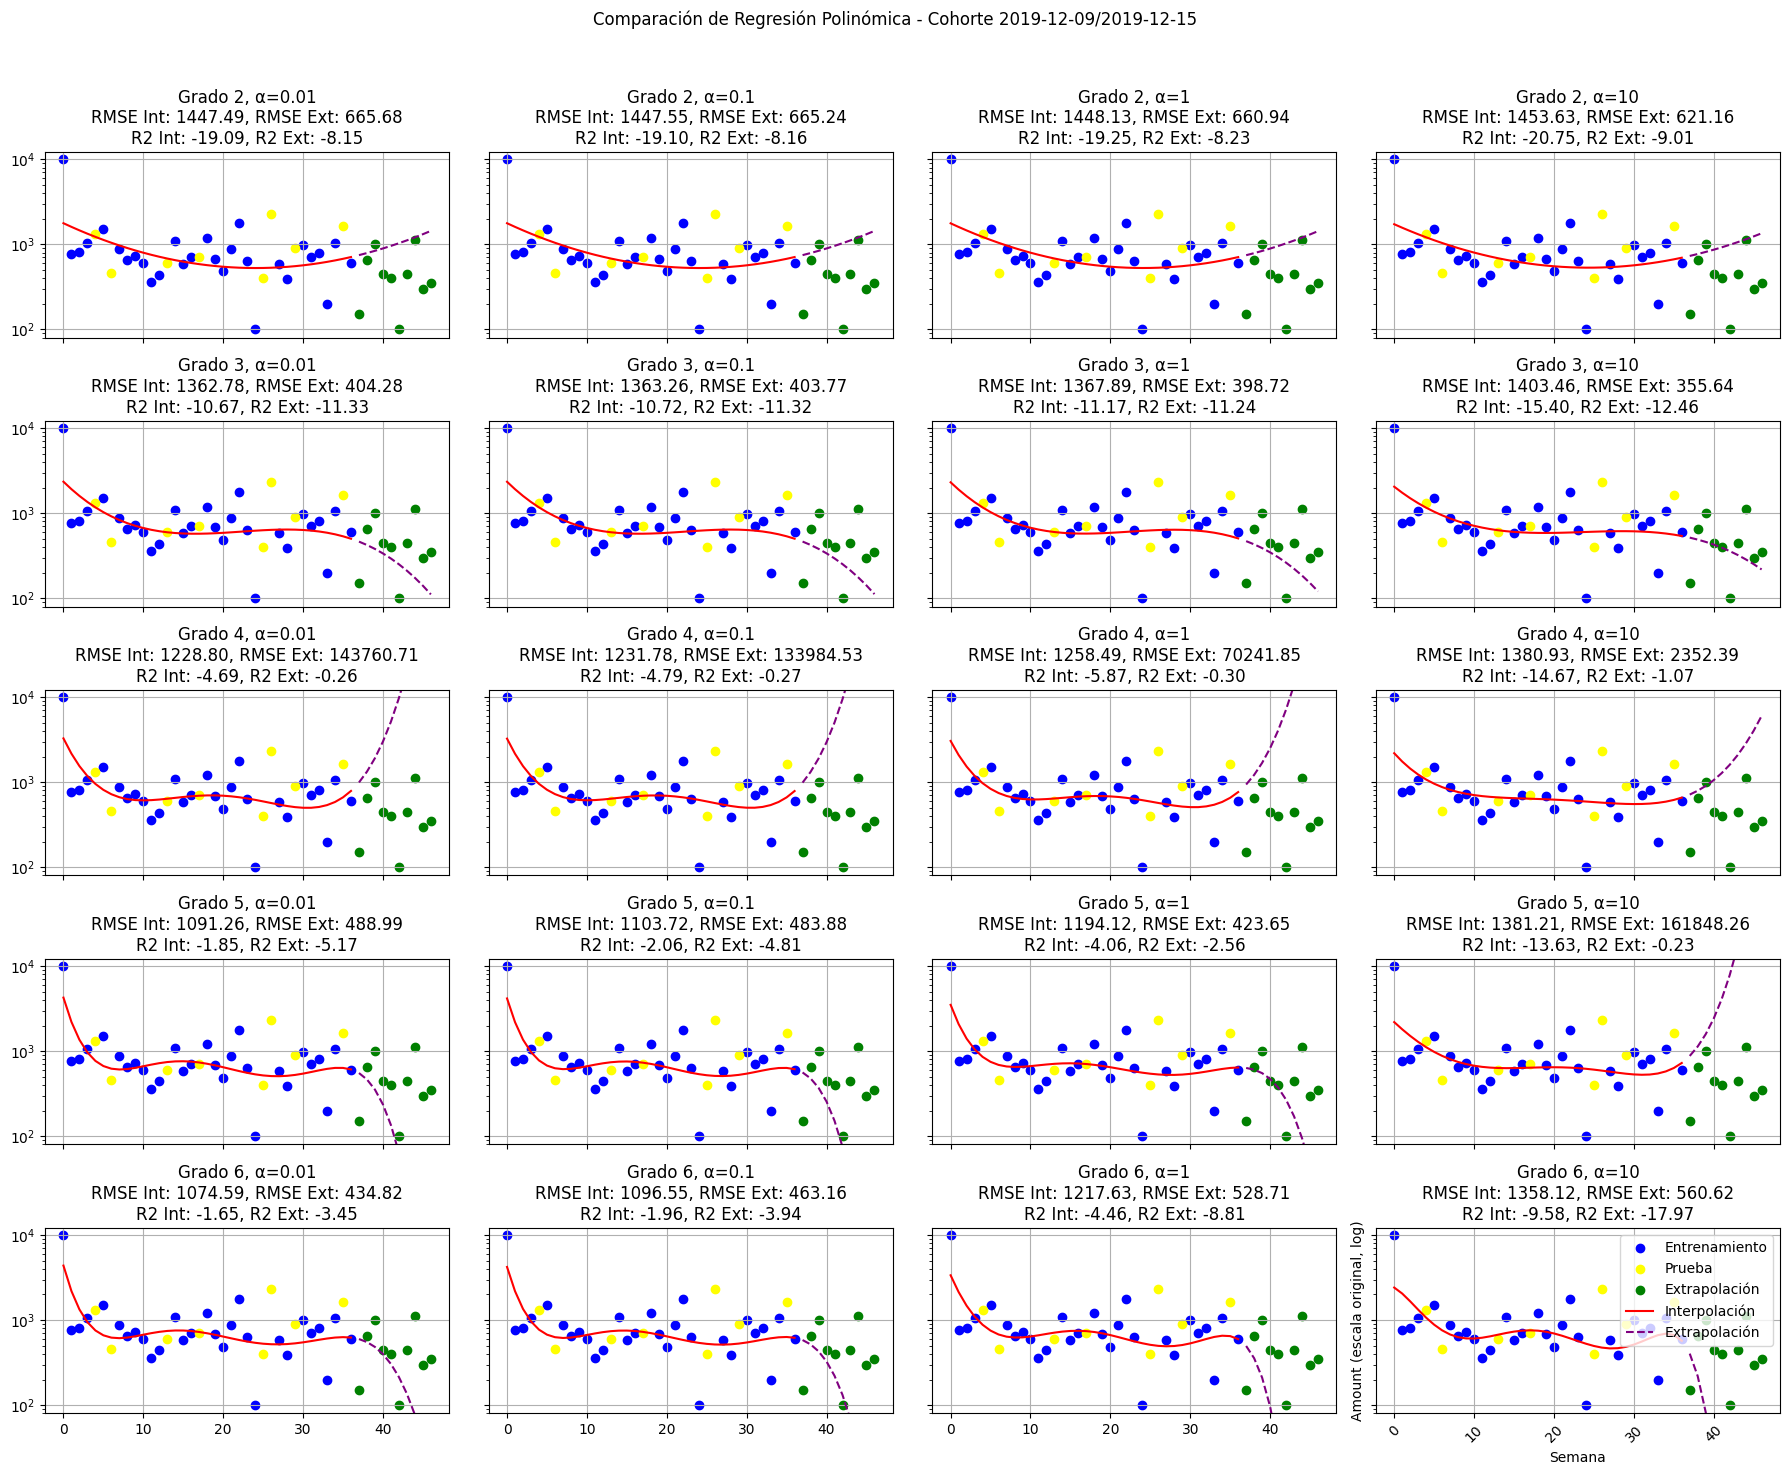

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Probar múltiples valores de `degree` y `alpha`
degrees = [2, 3, 4, 5, 6]  # Ahora agregamos 6
alphas = [0.01, 0.1, 1, 10]  # Ahora agregamos 10

fig, axes = plt.subplots(len(degrees), len(alphas), figsize=(18, 15), sharex=True, sharey=True)

# Determinar los límites del eje Y
y_min, y_max = np.expm1(y).min(), np.expm1(y).max()

for i, degree in enumerate(degrees):
    for j, alpha in enumerate(alphas):
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        X_interp_poly = poly.transform(X_interp)
        X_extrap_poly = poly.transform(X_extrap)

        model = Ridge(alpha=alpha)
        model.fit(X_train_poly, y_train)

        # Predicciones
        y_interp_pred = model.predict(X_interp_poly)
        y_extrap_pred = model.predict(X_extrap_poly)

        # Volver a la escala original
        y_interp_pred = np.expm1(y_interp_pred)
        y_extrap_pred = np.expm1(y_extrap_pred)
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_extrap_orig = np.expm1(y_extrap)

        # Evaluación del modelo
        rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
        rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
        r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
        r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

        # Graficar resultados
        ax = axes[i, j]
        ax.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
        ax.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
        ax.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

        # Líneas de tendencia
        ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación')
        ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación')

        # 🔹 Ajustar escala logarítmica en el eje Y
        ax.set_yscale('log')
        ax.set_ylim(y_min * 0.8, y_max * 1.2)

        ax.set_title(f"Grado {degree}, α={alpha}\nRMSE Int: {rmse_interp:.2f}, RMSE Ext: {rmse_extrap:.2f}\nR2 Int: {r2_interp:.2f}, R2 Ext: {r2_extrap:.2f}")
        ax.grid(True)

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original, log)")
plt.suptitle(f"Comparación de Regresión Polinómica - Cohorte {semana_objetivo}")
plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visibilidad
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajuste para título superior
plt.show()


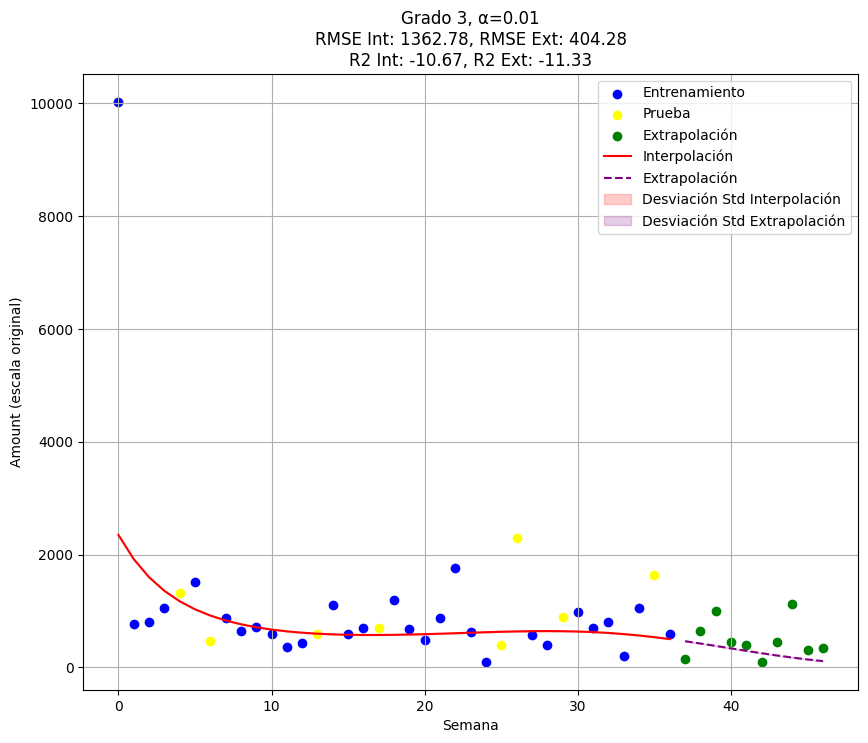

In [215]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Configurar grado y alpha específicos
degree = 3  # Grado 3 del polinomio
alpha = 0.01  # Parámetro alpha

# Transformar datos con el polinomio
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# Crear el modelo de Ridge y entrenarlo
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 🔹 7️⃣ Realizar predicciones
y_interp_pred = model.predict(X_interp_poly)
y_extrap_pred = model.predict(X_extrap_poly)

# Calcular errores (residuos) para estimar desviación estándar
y_interp_errors = y_interp - y_interp_pred
y_extrap_errors = y_extrap - y_extrap_pred

# Calcular desviación estándar de los errores
std_interp = np.std(y_interp_errors)
std_extrap = np.std(y_extrap_errors)

# Volver a la escala original
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 8️⃣ Evaluación del modelo
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

# 🔹 9️⃣ Graficar resultados
plt.figure(figsize=(10, 8))

# Datos de entrenamiento, prueba y extrapolación
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación')

# Añadir bandas de desviación estándar
plt.fill_between(X_interp.flatten(),
                 y_interp_pred - std_interp,
                 y_interp_pred + std_interp,
                 color='red', alpha=0.2, label='Desviación Std Interpolación')

plt.fill_between(X_extrap.flatten(),
                 y_extrap_pred - std_extrap,
                 y_extrap_pred + std_extrap,
                 color='purple', alpha=0.2, label='Desviación Std Extrapolación')

# Configuración de la gráfica (escala lineal)
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Grado {degree}, α={alpha}\nRMSE Int: {rmse_interp:.2f}, RMSE Ext: {rmse_extrap:.2f}\nR2 Int: {r2_interp:.2f}, R2 Ext: {r2_extrap:.2f}")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


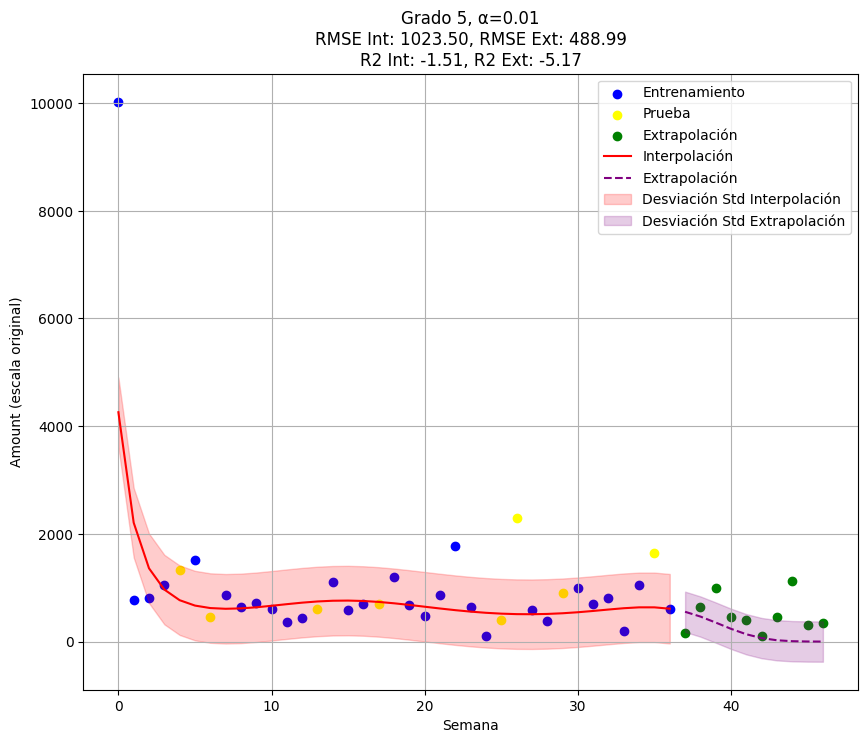

In [216]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Asegurar que los índices y columnas sean strings
cohort_revenue.index = cohort_revenue.index.astype(str)
cohort_revenue.columns = cohort_revenue.columns.astype(str)

# 🔹 2️⃣ Seleccionar la cohorte específica
semana_objetivo = '2019-12-09/2019-12-15'
if semana_objetivo in cohort_revenue.index:
    cohort_2019_12_09 = cohort_revenue.loc[semana_objetivo].dropna()
else:
    print(f"⚠️ La semana {semana_objetivo} no se encuentra en cohort_revenue.index")
    print("Índices disponibles:", list(cohort_revenue.index))
    raise KeyError(f"La semana {semana_objetivo} no está en los datos.")

# 🔹 3️⃣ Convertir semanas a variable numérica
X = np.arange(len(cohort_2019_12_09)).reshape(-1, 1)  # Índices numéricos
y = np.log1p(cohort_2019_12_09.values)  # Aplicar transformación logarítmica para manejar outliers

# 🔹 4️⃣ Dividir datos en entrenamiento (80%) y prueba (20%)
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 🔹 5️⃣ Dividir el 80% de interpolación en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 🔹 6️⃣ Configurar grado y alpha específicos
degree = 5  # Grado 3 del polinomio
alpha = 0.01  # Parámetro alpha

# Transformar datos con el polinomio
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# Crear el modelo de Ridge y entrenarlo
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 🔹 7️⃣ Realizar predicciones
y_interp_pred = model.predict(X_interp_poly)
y_extrap_pred = model.predict(X_extrap_poly)

# Volver a la escala original (revertir logaritmo)
y_interp_pred = np.expm1(y_interp_pred)  # Revertir transformación logarítmica
y_extrap_pred = np.expm1(y_extrap_pred)  # Revertir transformación logarítmica
y_train_orig = np.expm1(y_train)  # Revertir transformación logarítmica
y_test_orig = np.expm1(y_test)  # Revertir transformación logarítmica
y_extrap_orig = np.expm1(y_extrap)  # Revertir transformación logarítmica

# 🔹 8️⃣ Evaluación del modelo (ahora calculada correctamente)
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, y_interp))  # Usar y_interp para interpolación
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))  # Usar y_extrap_orig para extrapolación
r2_interp = r2_score(y_interp_pred, y_interp)  # Usar y_interp para interpolación
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)  # Usar y_extrap_orig para extrapolación

# 🔹 9️⃣ Graficar resultados
plt.figure(figsize=(10, 8))

# Datos de entrenamiento, prueba y extrapolación
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación')

# Añadir bandas de desviación estándar
std_interp = np.std(y_interp_pred - y_interp)
std_extrap = np.std(y_extrap_pred - y_extrap_orig)
plt.fill_between(X_interp.flatten(),
                 y_interp_pred.flatten() - std_interp,
                 y_interp_pred.flatten() + std_interp,
                 color='red', alpha=0.2, label='Desviación Std Interpolación')

plt.fill_between(X_extrap.flatten(),
                 y_extrap_pred.flatten() - std_extrap,
                 y_extrap_pred.flatten() + std_extrap,
                 color='purple', alpha=0.2, label='Desviación Std Extrapolación')

# Configuración de la gráfica (escala lineal)
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Grado {degree}, α={alpha}\nRMSE Int: {rmse_interp:.2f}, RMSE Ext: {rmse_extrap:.2f}\nR2 Int: {r2_interp:.2f}, R2 Ext: {r2_extrap:.2f}")
plt.legend()
plt.grid(True)
plt.show()


In [217]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Calcular métricas de error

# RMSE Absoluto
rmse_train = np.sqrt(mean_squared_error(y_train_orig, model.predict(X_train_poly)))
rmse_test = np.sqrt(mean_squared_error(y_test_orig, model.predict(X_test_poly)))
rmse_interp = np.sqrt(mean_squared_error(y_interp, y_interp_pred))  # Interpolación
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_orig, y_extrap_pred))  # Extrapolación

# RMSE Relativo
rmse_rel_train = rmse_train / np.mean(y_train_orig)
rmse_rel_test = rmse_test / np.mean(y_test_orig)
rmse_rel_interp = rmse_interp / np.mean(y_interp)
rmse_rel_extrap = rmse_extrap / np.mean(y_extrap_orig)

# R² (Coeficiente de Determinación)
r2_train = r2_score(y_train_orig, model.predict(X_train_poly))
r2_test = r2_score(y_test_orig, model.predict(X_test_poly))
r2_interp = r2_score(y_interp, y_interp_pred)  # Interpolación
r2_extrap = r2_score(y_extrap_orig, y_extrap_pred)  # Extrapolación

# 🔹 2️⃣ Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    "R² Entrenamiento": [r2_train, np.nan],
    "R² Prueba": [r2_test, np.nan],
    "Δ R² (Train - Test)": [r2_train - r2_test, np.nan],
    "R² Interpolación": [r2_interp, np.nan],
    "R² Extrapolación": [np.nan, r2_extrap],
    "RMSE Relativo Entrenamiento": [rmse_rel_train, np.nan],
    "RMSE Relativo Prueba": [rmse_rel_test, np.nan],
    "Δ RMSE Relativo (Train - Test)": [rmse_rel_train - rmse_rel_test, np.nan],
    "RMSE Relativo Interpolación": [rmse_rel_interp, np.nan],
    "RMSE Relativo Extrapolación": [np.nan, rmse_rel_extrap]
}, index=["Interpolación", "Extrapolación"])

# 🔹 3️⃣ Mostrar métricas
print(metrics_df)


               R² Entrenamiento  R² Prueba  Δ R² (Train - Test)  \
Interpolación         -0.384211   -2.75618             2.371968   
Extrapolación               NaN        NaN                  NaN   

               R² Interpolación  R² Extrapolación  \
Interpolación     -2.032874e+06               NaN   
Extrapolación               NaN          -1.32288   

               RMSE Relativo Entrenamiento  RMSE Relativo Prueba  \
Interpolación                     1.885525              1.160197   
Extrapolación                          NaN                   NaN   

               Δ RMSE Relativo (Train - Test)  RMSE Relativo Interpolación  \
Interpolación                        0.725328                   154.295199   
Extrapolación                             NaN                          NaN   

               RMSE Relativo Extrapolación  
Interpolación                          NaN  
Extrapolación                     0.981901  


    Grado  RMSE Entrenamiento   RMSE Prueba  R² Entrenamiento     R² Prueba
0       1        1.686668e+03  7.829312e+02      4.587682e-02 -5.814790e-01
1       2        1.586093e+03  7.557079e+02      1.562718e-01 -4.734118e-01
2       3        1.489784e+03  7.374965e+02      2.556246e-01 -4.032537e-01
3       4        1.332907e+03  7.369864e+02      4.041388e-01 -4.013133e-01
4       5        1.164639e+03  7.686018e+02      5.450876e-01 -5.241195e-01
5       6        1.144971e+03  7.671072e+02      5.603223e-01 -5.181978e-01
6       7        9.543365e+02  7.667256e+02      6.945443e-01 -5.166877e-01
7       8        5.164553e+02  8.836632e+02      9.105437e-01 -1.014604e+00
8       9        4.121777e+02  8.575040e+02      9.430211e-01 -8.970925e-01
9      10        4.166278e+02  8.561428e+02      9.417841e-01 -8.910744e-01
10     11        3.474983e+02  7.566969e+02      9.595004e-01 -4.772710e-01
11     12        1.597221e+05  1.095093e+04     -8.555092e+03 -3.083987e+02
12     13   

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.10942e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.31175e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.74273e-28): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

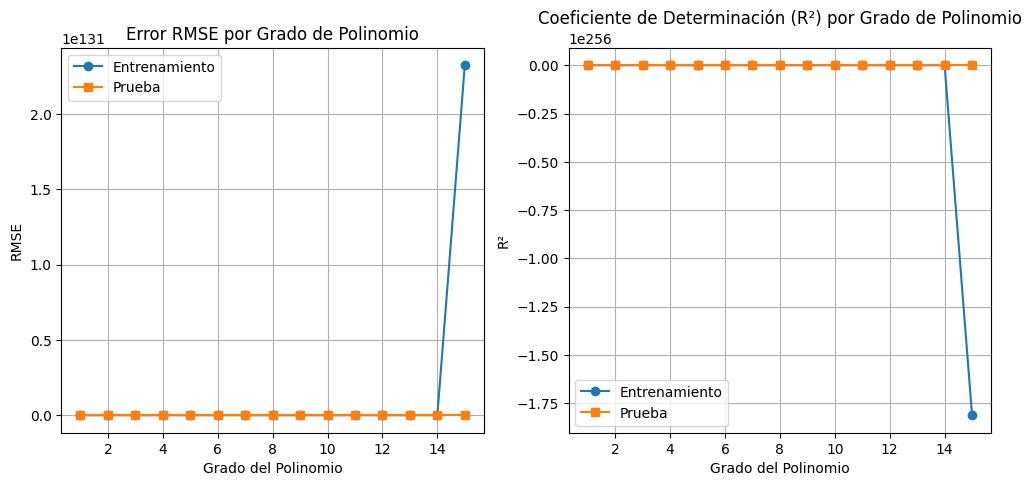

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Definir rango de grados de polinomio a probar
degrees = range(1, 16)

# Almacenar resultados
results = []

# Iterar sobre cada grado de polinomio
for degree in degrees:
    # Transformación polinómica
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Modelo Ridge con alpha fijo
    alpha = 0.01  # Se puede ajustar si es necesario
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    # Predicciones
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Revertir transformación logarítmica
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_pred_orig = np.expm1(y_test_pred)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)

    # Calcular métricas de error
    rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
    rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    r2_train = r2_score(y_train_orig, y_train_pred_orig)
    r2_test = r2_score(y_test_orig, y_test_pred_orig)

    # Almacenar resultados
    results.append([degree, rmse_train, rmse_test, r2_train, r2_test])

# Crear DataFrame con los resultados
df_results = pd.DataFrame(results, columns=["Grado", "RMSE Entrenamiento", "RMSE Prueba", "R² Entrenamiento", "R² Prueba"])

# Mostrar DataFrame con los resultados
print(df_results)

# Graficar RMSE y R² en función del grado del polinomio
plt.figure(figsize=(12, 5))

# RMSE
plt.subplot(1, 2, 1)
plt.plot(df_results["Grado"], df_results["RMSE Entrenamiento"], marker='o', label="Entrenamiento")
plt.plot(df_results["Grado"], df_results["RMSE Prueba"], marker='s', label="Prueba")
plt.xlabel("Grado del Polinomio")
plt.ylabel("RMSE")
plt.title("Error RMSE por Grado de Polinomio")
plt.legend()
plt.grid(True)

# R²
plt.subplot(1, 2, 2)
plt.plot(df_results["Grado"], df_results["R² Entrenamiento"], marker='o', label="Entrenamiento")
plt.plot(df_results["Grado"], df_results["R² Prueba"], marker='s', label="Prueba")
plt.xlabel("Grado del Polinomio")
plt.ylabel("R²")
plt.title("Coeficiente de Determinación (R²) por Grado de Polinomio")
plt.legend()
plt.grid(True)

plt.show()


In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 1️⃣ Seleccionar solo el 80% de los datos para interpolación
X_interp, y_interp = X[:split_idx], y[:split_idx]  # Tomar solo el 80% de los datos

# 🔹 2️⃣ Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.15, random_state=42)

# 🔹 3️⃣ Transformación polinómica (con grado definido)
degree = 11  # Puedes ajustar el grado si es necesario
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 🔹 4️⃣ Modelo de Ridge para interpolación
alpha = 0.01  # Parámetro de regularización
model_interp = Ridge(alpha=alpha)
model_interp.fit(X_train_poly, y_train)

# 🔹 5️⃣ Realizar predicciones
y_train_pred = model_interp.predict(X_train_poly)
y_test_pred = model_interp.predict(X_test_poly)

# 🔹 6️⃣ Revertir transformación logarítmica
y_train_pred_orig = np.expm1(y_train_pred)
y_test_pred_orig = np.expm1(y_test_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)

# 🔹 7️⃣ Calcular métricas de error
rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
r2_train = r2_score(y_train_orig, y_train_pred_orig)
r2_test = r2_score(y_test_orig, y_test_pred_orig)

# 🔹 8️⃣ Crear DataFrame con métricas
metrics_interp = pd.DataFrame({
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
}, index=["Entrenamiento", "Prueba"])

# 🔹 9️⃣ Mostrar métricas
print(metrics_interp)


                     RMSE        R²
Entrenamiento  482.278197  0.918372
Prueba         164.998061  0.851467


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.19434e-37): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


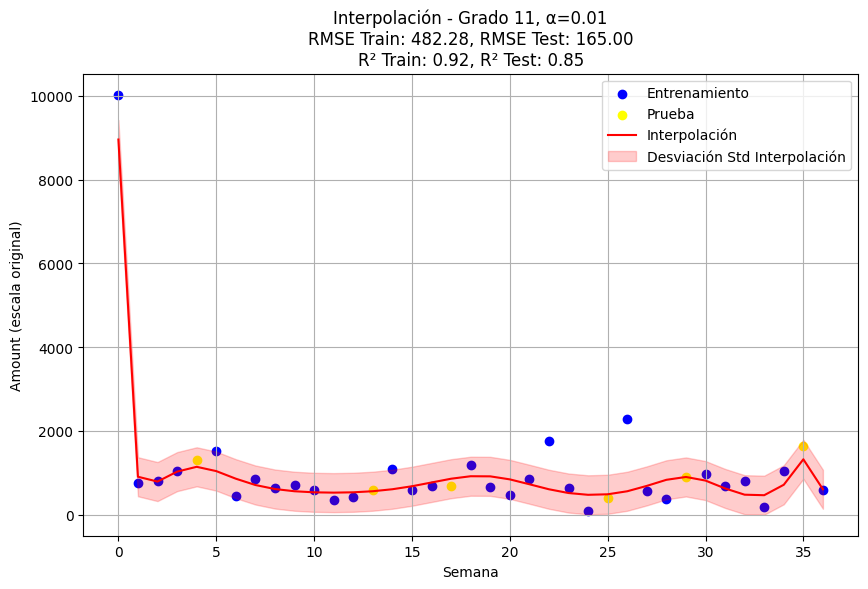

In [220]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 1️⃣ Graficar resultados de la interpolación
plt.figure(figsize=(10, 6))

# Datos de entrenamiento y prueba
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')

# Línea de predicción del modelo
X_interp_sorted = np.sort(X_interp, axis=0)  # Ordenar X para graficar correctamente
X_interp_poly_sorted = poly.transform(X_interp_sorted)
y_interp_pred_sorted = model_interp.predict(X_interp_poly_sorted)
y_interp_pred_sorted_orig = np.expm1(y_interp_pred_sorted)  # Revertir logaritmo

plt.plot(X_interp_sorted, y_interp_pred_sorted_orig, color='red', linestyle='-', label='Interpolación')

# Bandas de desviación estándar
std_interp = np.std(y_train_orig - y_train_pred_orig)
plt.fill_between(X_interp_sorted.flatten(),
                 y_interp_pred_sorted_orig.flatten() - std_interp,
                 y_interp_pred_sorted_orig.flatten() + std_interp,
                 color='red', alpha=0.2, label='Desviación Std Interpolación')

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Interpolación - Grado {degree}, α={alpha}\nRMSE Train: {rmse_train:.2f}, RMSE Test: {rmse_test:.2f}\nR² Train: {r2_train:.2f}, R² Test: {r2_test:.2f}")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.30968e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.14064e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.09956e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.19902e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

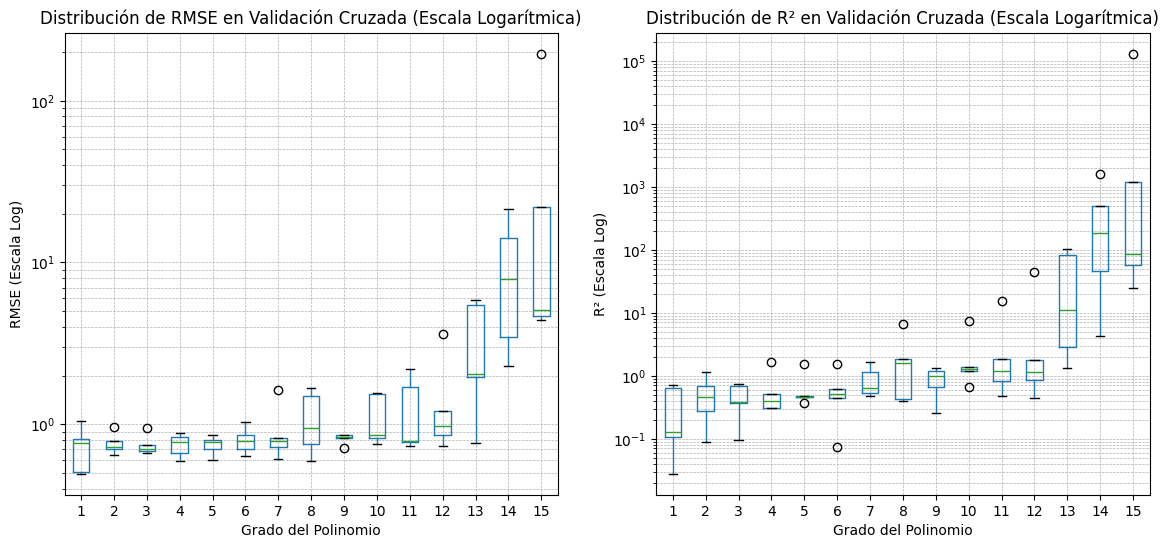

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Definir rango de grados de polinomio a probar
degrees = range(1, 16)

# Configurar validación cruzada con K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar resultados para los boxplots de RMSE y R²
rmse_scores = {degree: [] for degree in degrees}
r2_scores = {degree: [] for degree in degrees}

# Iterar sobre cada grado de polinomio
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X_interp)  # Aplicar transformación polinómica

    # Modelo Ridge con alpha fijo
    alpha = 0.01  # Se puede ajustar si es necesario
    model = Ridge(alpha=alpha)

    # Validación cruzada con RMSE y R²
    mse_cv_scores = cross_val_score(model, X_poly, y_interp, cv=kf, scoring=make_scorer(mean_squared_error))
    r2_cv_scores = cross_val_score(model, X_poly, y_interp, cv=kf, scoring=make_scorer(r2_score))

    # Guardar RMSE (Raíz de MSE) y R²
    rmse_scores[degree] = np.sqrt(np.abs(mse_cv_scores))  # Convertir MSE a RMSE
    r2_scores[degree] = np.abs(r2_cv_scores)  # Convertir R² a valores absolutos para escala logarítmica

# Crear DataFrames para los boxplots
df_rmse = pd.DataFrame.from_dict(rmse_scores, orient="index").T
df_r2 = pd.DataFrame.from_dict(r2_scores, orient="index").T

# 🔹 Graficar boxplots de RMSE y R² en escala logarítmica
plt.figure(figsize=(14, 6))

# Boxplot de RMSE
plt.subplot(1, 2, 1)
df_rmse.boxplot()
plt.yscale("log")  # Aplicar escala logarítmica
plt.xlabel("Grado del Polinomio")
plt.ylabel("RMSE (Escala Log)")
plt.title("Distribución de RMSE en Validación Cruzada (Escala Logarítmica)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Boxplot de R²
plt.subplot(1, 2, 2)
df_r2.boxplot()
plt.yscale("log")  # Aplicar escala logarítmica
plt.xlabel("Grado del Polinomio")
plt.ylabel("R² (Escala Log)")
plt.title("Distribución de R² en Validación Cruzada (Escala Logarítmica)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.29127e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


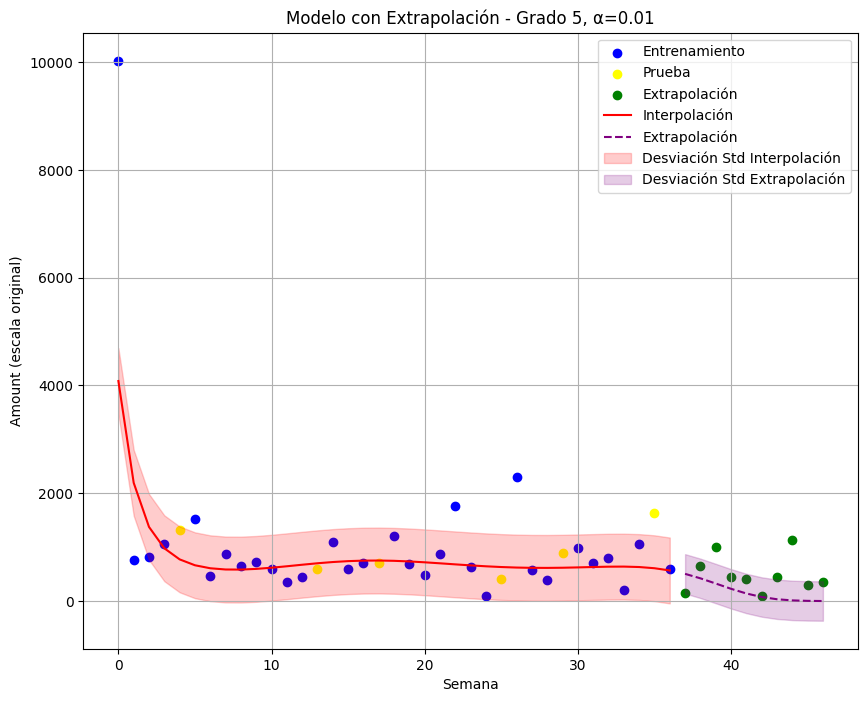

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# 🔹 1️⃣ Definir el grado del polinomio y el modelo Ridge
degree = 5  # Puedes ajustar el grado si es necesario
alpha = 0.01  # Parámetro de regularización

# 🔹 2️⃣ Transformar datos con polinomio
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 🔹 3️⃣ Entrenar modelo Ridge
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 🔹 4️⃣ Hacer predicciones
y_interp_pred = model.predict(X_interp_poly)
y_extrap_pred = model.predict(X_extrap_poly)

# 🔹 5️⃣ Revertir transformación logarítmica
y_interp_pred_orig = np.expm1(y_interp_pred)
y_extrap_pred_orig = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 6️⃣ Graficar resultados con extrapolación
plt.figure(figsize=(10, 8))

# Datos de entrenamiento, prueba y extrapolación
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred_orig, color='red', linestyle='-', label='Interpolación')
plt.plot(X_extrap, y_extrap_pred_orig, color='purple', linestyle='--', label='Extrapolación')

# Añadir bandas de desviación estándar
std_interp = np.std(y_interp_pred_orig - y_interp)
std_extrap = np.std(y_extrap_pred_orig - y_extrap_orig)
plt.fill_between(X_interp.flatten(),
                 y_interp_pred_orig.flatten() - std_interp,
                 y_interp_pred_orig.flatten() + std_interp,
                 color='red', alpha=0.2, label='Desviación Std Interpolación')

plt.fill_between(X_extrap.flatten(),
                 y_extrap_pred_orig.flatten() - std_extrap,
                 y_extrap_pred_orig.flatten() + std_extrap,
                 color='purple', alpha=0.2, label='Desviación Std Extrapolación')

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Modelo con Extrapolación - Grado {degree}, α={alpha}")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.00227e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


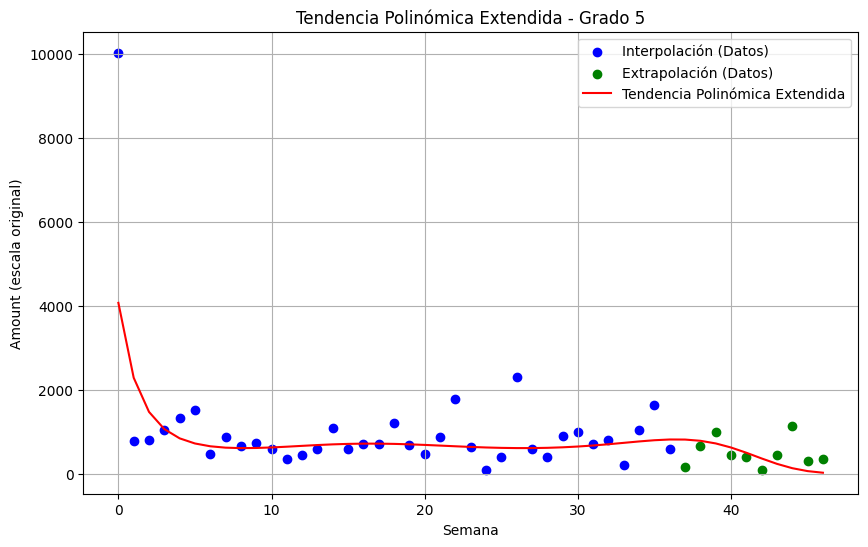

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 🔹 1️⃣ Definir grado y transformar datos
degree = 5  # Puedes ajustar el grado si es necesario
poly = PolynomialFeatures(degree)
X_interp_poly = poly.fit_transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 🔹 2️⃣ Usar el modelo de interpolación y predecir sobre extrapolación
model_interp = Ridge(alpha=0.01)
model_interp.fit(X_interp_poly, y_interp)

# Predicciones en interpolación y extrapolación
y_interp_pred = model_interp.predict(X_interp_poly)
y_extrap_pred = model_interp.predict(X_extrap_poly)

# 🔹 3️⃣ Revertir transformación logarítmica
y_interp_pred_orig = np.expm1(y_interp_pred)
y_extrap_pred_orig = np.expm1(y_extrap_pred)
y_interp_orig = np.expm1(y_interp)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 4️⃣ Extender la línea de tendencia polinómica en extrapolación
X_full = np.vstack([X_interp, X_extrap])  # Unir interpolación y extrapolación
X_full_sorted = np.sort(X_full, axis=0)  # Ordenar para la línea de tendencia
X_full_poly = poly.transform(X_full_sorted)
y_full_pred = model_interp.predict(X_full_poly)
y_full_pred_orig = np.expm1(y_full_pred)  # Revertir logaritmo

# 🔹 5️⃣ Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales
plt.scatter(X_interp, y_interp_orig, color='blue', label='Interpolación (Datos)')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación (Datos)')

# Línea de tendencia polinómica extendida
plt.plot(X_full_sorted, y_full_pred_orig, color='red', linestyle='-', label='Tendencia Polinómica Extendida')

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Tendencia Polinómica Extendida - Grado {degree}")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.00227e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


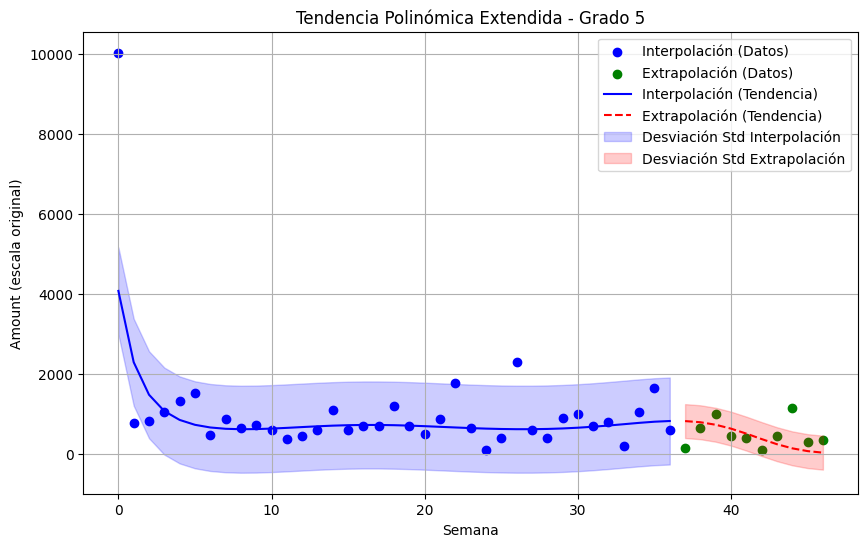

In [224]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 🔹 1️⃣ Definir grado del polinomio y transformar datos
degree = 5  # Puedes ajustar el grado
poly = PolynomialFeatures(degree)
X_interp_poly = poly.fit_transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 🔹 2️⃣ Usar el modelo de interpolación y predecir sobre extrapolación
model_interp = Ridge(alpha=0.01)
model_interp.fit(X_interp_poly, y_interp)

# Predicciones en interpolación y extrapolación
y_interp_pred = model_interp.predict(X_interp_poly)
y_extrap_pred = model_interp.predict(X_extrap_poly)

# 🔹 3️⃣ Revertir transformación logarítmica
y_interp_pred_orig = np.expm1(y_interp_pred)
y_extrap_pred_orig = np.expm1(y_extrap_pred)
y_interp_orig = np.expm1(y_interp)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 4️⃣ Calcular la desviación estándar
std_interp = np.std(y_interp_orig - y_interp_pred_orig)
std_extrap = np.std(y_extrap_orig - y_extrap_pred_orig)

# 🔹 5️⃣ Extender la línea de tendencia polinómica en extrapolación
X_full = np.vstack([X_interp, X_extrap])  # Unir interpolación y extrapolación
X_full_sorted = np.sort(X_full, axis=0)  # Ordenar para la línea de tendencia
X_full_poly = poly.transform(X_full_sorted)
y_full_pred = model_interp.predict(X_full_poly)
y_full_pred_orig = np.expm1(y_full_pred)  # Revertir logaritmo

# Dividir la línea de tendencia en dos partes: interpolación y extrapolación
split_index = len(X_interp)
X_interp_sorted = X_full_sorted[:split_index]
X_extrap_sorted = X_full_sorted[split_index:]
y_interp_pred_sorted = y_full_pred_orig[:split_index]
y_extrap_pred_sorted = y_full_pred_orig[split_index:]

# 🔹 6️⃣ Graficar resultados con sombreado y cambio de color
plt.figure(figsize=(10, 6))

# Datos originales
plt.scatter(X_interp, y_interp_orig, color='blue', label='Interpolación (Datos)')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación (Datos)')

# Línea de tendencia polinómica: azul en interpolación, rojo en extrapolación
plt.plot(X_interp_sorted, y_interp_pred_sorted, color='blue', linestyle='-', label='Interpolación (Tendencia)')
plt.plot(X_extrap_sorted, y_extrap_pred_sorted, color='red', linestyle='--', label='Extrapolación (Tendencia)')

# Sombreado con desviación estándar
plt.fill_between(X_interp_sorted.flatten(),
                 y_interp_pred_sorted.flatten() - std_interp,
                 y_interp_pred_sorted.flatten() + std_interp,
                 color='blue', alpha=0.2, label='Desviación Std Interpolación')

plt.fill_between(X_extrap_sorted.flatten(),
                 y_extrap_pred_sorted.flatten() - std_extrap,
                 y_extrap_pred_sorted.flatten() + std_extrap,
                 color='red', alpha=0.2, label='Desviación Std Extrapolación')

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Tendencia Polinómica Extendida - Grado {degree}")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.00227e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


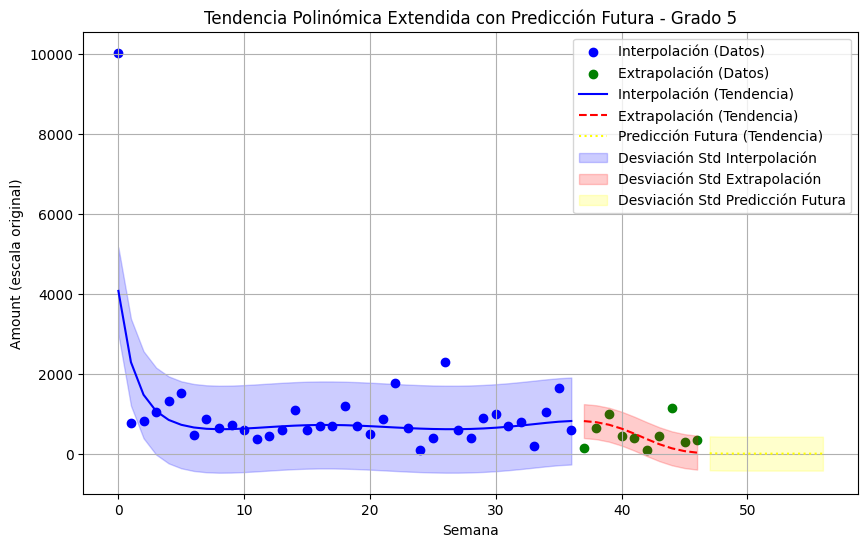

In [225]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 🔹 1️⃣ Definir grado del polinomio y transformar datos
degree = 5  # Puedes ajustar el grado
poly = PolynomialFeatures(degree)
X_interp_poly = poly.fit_transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 🔹 2️⃣ Usar el modelo de interpolación y predecir sobre extrapolación
model_interp = Ridge(alpha=0.01)
model_interp.fit(X_interp_poly, y_interp)

# Predicciones en interpolación y extrapolación
y_interp_pred = model_interp.predict(X_interp_poly)
y_extrap_pred = model_interp.predict(X_extrap_poly)

# 🔹 3️⃣ Revertir transformación logarítmica
y_interp_pred_orig = np.expm1(y_interp_pred)
y_extrap_pred_orig = np.expm1(y_extrap_pred)
y_interp_orig = np.expm1(y_interp)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 4️⃣ Calcular la desviación estándar
std_interp = np.std(y_interp_orig - y_interp_pred_orig)
std_extrap = np.std(y_extrap_orig - y_extrap_pred_orig)

# 🔹 5️⃣ Extender la predicción más semanas al futuro
num_future_weeks = 10  # Número de semanas a predecir
X_future = np.arange(X_extrap.max() + 1, X_extrap.max() + 1 + num_future_weeks).reshape(-1, 1)
X_future_poly = poly.transform(X_future)
y_future_pred = model_interp.predict(X_future_poly)
y_future_pred_orig = np.expm1(y_future_pred)  # Revertir transformación logarítmica

# 🔹 6️⃣ Extender la línea de tendencia polinómica en extrapolación y predicción futura
X_full = np.vstack([X_interp, X_extrap, X_future])  # Unir interpolación, extrapolación y futuro
X_full_sorted = np.sort(X_full, axis=0)  # Ordenar para la línea de tendencia
X_full_poly = poly.transform(X_full_sorted)
y_full_pred = model_interp.predict(X_full_poly)
y_full_pred_orig = np.expm1(y_full_pred)  # Revertir logaritmo

# Dividir la línea de tendencia en tres partes: interpolación, extrapolación y predicción futura
split_interp = len(X_interp)
split_extrap = len(X_interp) + len(X_extrap)
X_interp_sorted = X_full_sorted[:split_interp]
X_extrap_sorted = X_full_sorted[split_interp:split_extrap]
X_future_sorted = X_full_sorted[split_extrap:]
y_interp_pred_sorted = y_full_pred_orig[:split_interp]
y_extrap_pred_sorted = y_full_pred_orig[split_interp:split_extrap]
y_future_pred_sorted = y_full_pred_orig[split_extrap:]

# 🔹 7️⃣ Graficar resultados con sombreado y predicciones futuras
plt.figure(figsize=(10, 6))

# Datos originales
plt.scatter(X_interp, y_interp_orig, color='blue', label='Interpolación (Datos)')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación (Datos)')

# Línea de tendencia polinómica: azul en interpolación, rojo en extrapolación, amarillo en futuro
plt.plot(X_interp_sorted, y_interp_pred_sorted, color='blue', linestyle='-', label='Interpolación (Tendencia)')
plt.plot(X_extrap_sorted, y_extrap_pred_sorted, color='red', linestyle='--', label='Extrapolación (Tendencia)')
plt.plot(X_future_sorted, y_future_pred_sorted, color='yellow', linestyle=':', label='Predicción Futura (Tendencia)')

# Sombreado con desviación estándar
plt.fill_between(X_interp_sorted.flatten(),
                 y_interp_pred_sorted.flatten() - std_interp,
                 y_interp_pred_sorted.flatten() + std_interp,
                 color='blue', alpha=0.2, label='Desviación Std Interpolación')

plt.fill_between(X_extrap_sorted.flatten(),
                 y_extrap_pred_sorted.flatten() - std_extrap,
                 y_extrap_pred_sorted.flatten() + std_extrap,
                 color='red', alpha=0.2, label='Desviación Std Extrapolación')

plt.fill_between(X_future_sorted.flatten(),
                 y_future_pred_sorted.flatten() - std_extrap,
                 y_future_pred_sorted.flatten() + std_extrap,
                 color='yellow', alpha=0.2, label='Desviación Std Predicción Futura')

# Configuración de la gráfica
plt.xlabel("Semana")
plt.ylabel("Amount (escala original)")
plt.title(f"Tendencia Polinómica Extendida con Predicción Futura - Grado {degree}")
plt.legend()
plt.grid(True)
plt.show()


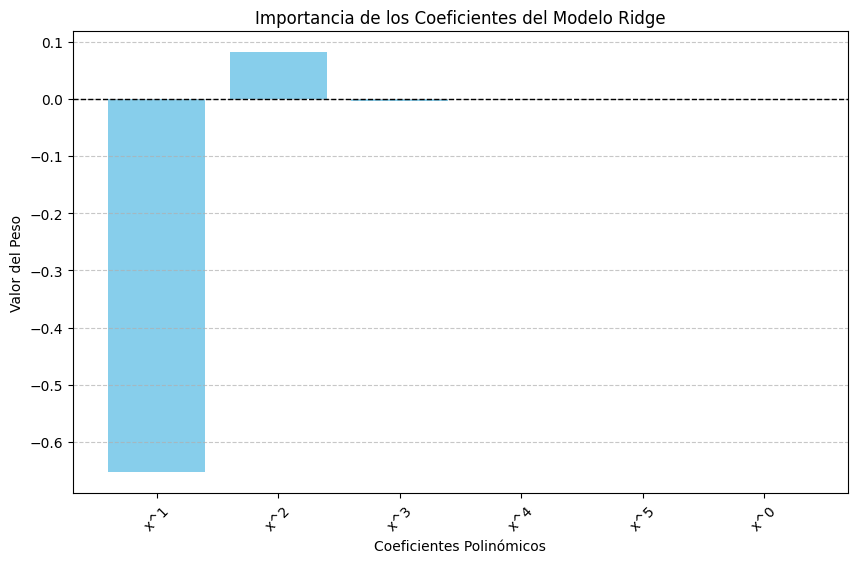

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 1️⃣ Extraer coeficientes del modelo Ridge
coefs = model_interp.coef_.flatten()  # Extrae los pesos del modelo

# 🔹 2️⃣ Crear etiquetas para cada coeficiente (correspondientes a las características polinómicas)
feature_labels = [f"x^{i}" for i in range(len(coefs))]  # Etiquetas x^0, x^1, x^2...

# 🔹 3️⃣ Crear un DataFrame ordenado por la magnitud del coeficiente
df_coefs = pd.DataFrame({"Feature": feature_labels, "Peso": coefs})
df_coefs["Peso Abs"] = np.abs(df_coefs["Peso"])  # Tomamos el valor absoluto para ordenar
df_coefs = df_coefs.sort_values(by="Peso Abs", ascending=False)

# 🔹 4️⃣ Graficar los coeficientes en un gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_coefs["Feature"], df_coefs["Peso"], color="skyblue")
plt.axhline(0, color="black", linewidth=1, linestyle="--")  # Línea de referencia en 0

# Configuración del gráfico
plt.xlabel("Coeficientes Polinómicos")
plt.ylabel("Valor del Peso")
plt.title("Importancia de los Coeficientes del Modelo Ridge")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



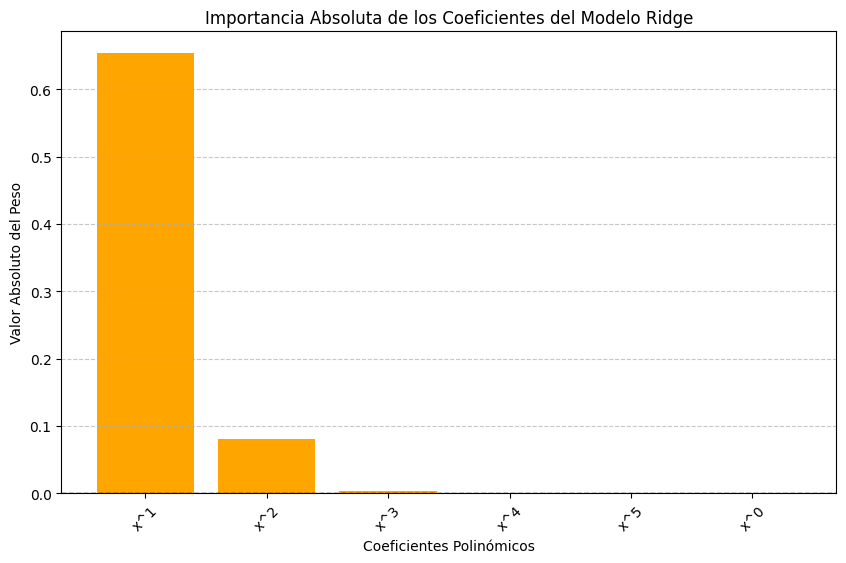

In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 1️⃣ Obtener los valores absolutos de los coeficientes
coefs_abs = np.abs(model_interp.coef_.flatten())

# 🔹 2️⃣ Crear etiquetas para cada coeficiente polinómico
feature_labels = [f"x^{i}" for i in range(len(coefs_abs))]  # Etiquetas: x^0, x^1, x^2...

# 🔹 3️⃣ Crear un DataFrame y ordenarlo por magnitud del coeficiente
df_coefs_abs = pd.DataFrame({"Feature": feature_labels, "Peso Abs": coefs_abs})
df_coefs_abs = df_coefs_abs.sort_values(by="Peso Abs", ascending=False)

# 🔹 4️⃣ Graficar los coeficientes en un gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_coefs_abs["Feature"], df_coefs_abs["Peso Abs"], color="orange")
plt.axhline(0, color="black", linewidth=1, linestyle="--")  # Línea de referencia en 0

# Configuración del gráfico
plt.xlabel("Coeficientes Polinómicos")
plt.ylabel("Valor Absoluto del Peso")
plt.title("Importancia Absoluta de los Coeficientes del Modelo Ridge")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.018e+03, tolerance: 3.275e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.418e+01, tolerance: 3.275e+01
  model = cd_fast.enet_coordinate_descent(


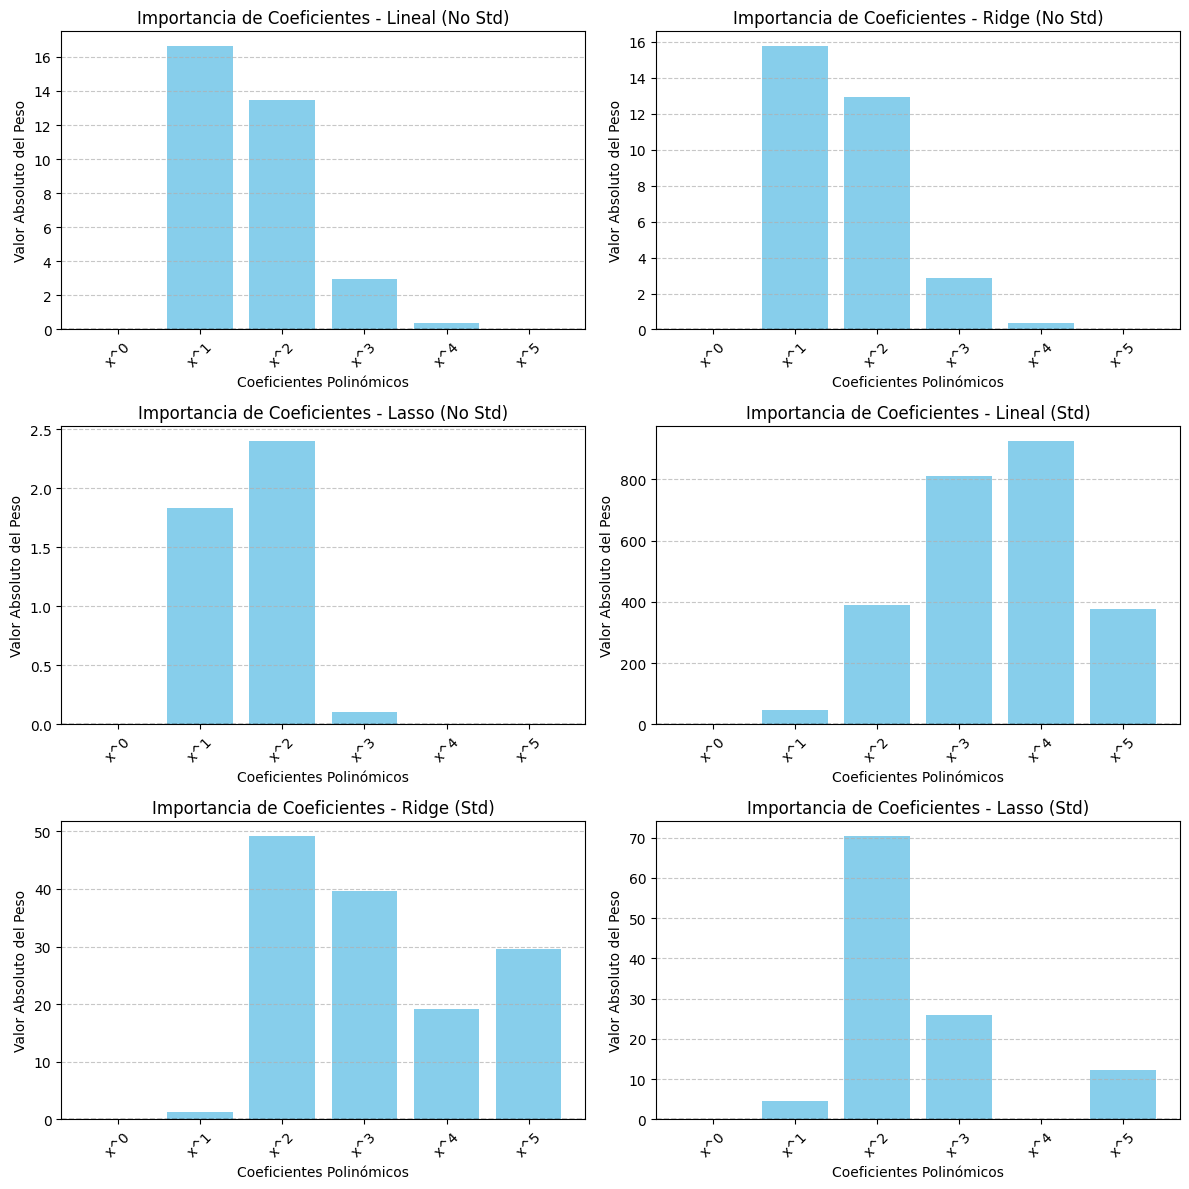

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import make_pipeline

# 🔹 1️⃣ Generar datos de muestra
np.random.seed(42)
X_sample = np.random.rand(50, 1) * 10  # 50 muestras en el rango [0,10]
y_sample = 3 * X_sample.flatten()**2 - 2 * X_sample.flatten() + np.random.randn(50) * 10  # Relación cuadrática con ruido

# 🔹 2️⃣ Definir grado del polinomio y transformar los datos
degree = 5
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X_sample)

# 🔹 3️⃣ Crear modelos sin estandarizar
model_lin = LinearRegression()
model_ridge = Ridge(alpha=0.01)
model_lasso = Lasso(alpha=0.01)

# 🔹 4️⃣ Crear modelos con estandarización
model_lin_std = make_pipeline(StandardScaler(), LinearRegression())
model_ridge_std = make_pipeline(StandardScaler(), Ridge(alpha=0.01))
model_lasso_std = make_pipeline(StandardScaler(), Lasso(alpha=0.01))

# 🔹 5️⃣ Ajustar los modelos a los datos polinomiales
model_lin.fit(X_poly, y_sample)
model_ridge.fit(X_poly, y_sample)
model_lasso.fit(X_poly, y_sample)

# Ajustar modelos estandarizados
model_lin_std.fit(X_poly, y_sample)
model_ridge_std.fit(X_poly, y_sample)
model_lasso_std.fit(X_poly, y_sample)

# 🔹 6️⃣ Extraer coeficientes absolutos
coefs = {
    "Lineal (No Std)": np.abs(model_lin.coef_.flatten()),
    "Ridge (No Std)": np.abs(model_ridge.coef_.flatten()),
    "Lasso (No Std)": np.abs(model_lasso.coef_.flatten()),
    "Lineal (Std)": np.abs(model_lin_std.named_steps["linearregression"].coef_.flatten()),
    "Ridge (Std)": np.abs(model_ridge_std.named_steps["ridge"].coef_.flatten()),
    "Lasso (Std)": np.abs(model_lasso_std.named_steps["lasso"].coef_.flatten())
}

# 🔹 7️⃣ Crear etiquetas de coeficientes polinómicos
feature_labels = [f"x^{i}" for i in range(len(coefs["Lineal (No Std)"]))]

# 🔹 8️⃣ Graficar comparación de coeficientes para cada modelo
model_names = list(coefs.keys())

plt.figure(figsize=(12, 12))
for i, model in enumerate(model_names, 1):
    plt.subplot(3, 2, i)
    plt.bar(feature_labels, coefs[model], color="skyblue")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")  # Línea base en 0
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor Absoluto del Peso")
    plt.title(f"Importancia de Coeficientes - {model}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


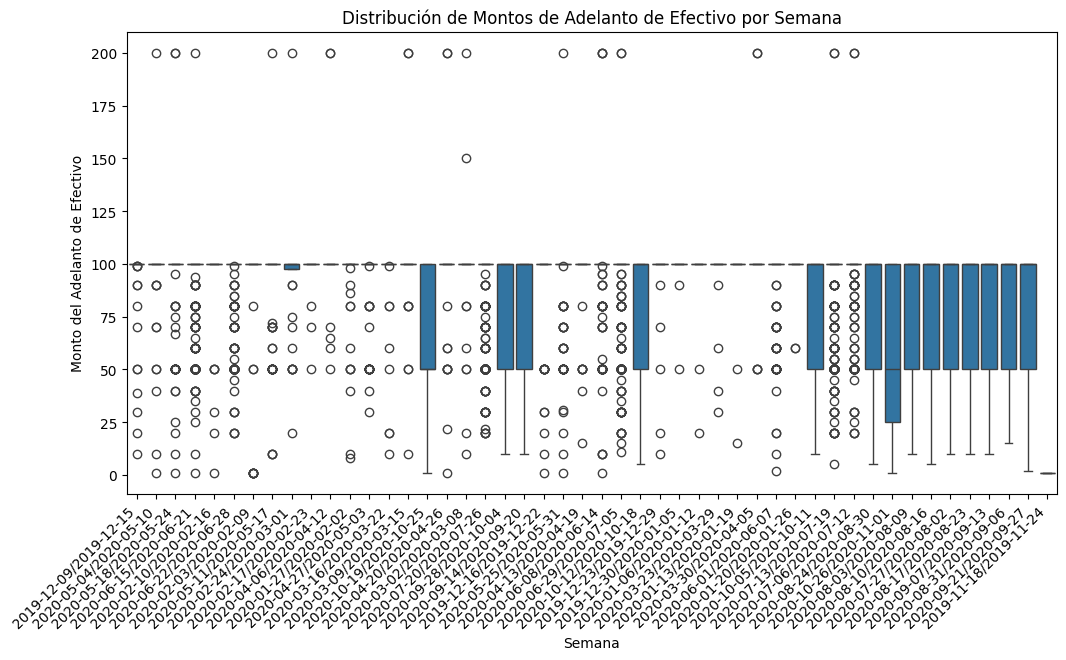

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear el boxplot
sns.boxplot(data=cr, x="Semana", y="amount")

# Ajustar el formato del eje X para mejorar la legibilidad
plt.xticks(rotation=45, ha="right")

# Etiquetas y título
plt.xlabel("Semana")
plt.ylabel("Monto del Adelanto de Efectivo")
plt.title("Distribución de Montos de Adelanto de Efectivo por Semana")

# Mostrar el gráfico
plt.show()
